# Results figures and tables — the calibrated clearing model

Every results-section graphic and table, rendered inline and also saved to
`output/results/*.png` (dpi 150). This notebook is the single source of truth for
the results figures (it supersedes the old `scripts/make_results.py`).

It reads the behavioural $\theta$ straight from `model.globals.CALIBRATED[regime]`,
so it picks up the **wired re-lock $\theta$** automatically with no edits here.

**Part A — descriptive** (one short sim per regime; a stressed window runs in
~10 s): **A** order flow (buy/sell-initiated volume + bid/ask depth), **B**
capital-ratio $\kappa_t$ drawdown paths with the regulatory floors, **C** IM
decomposition with the procyclical IM fraction `im_fraction(`$\sigma_t$`)`, **D**
posted IM by participant type (FT/MT/ZI clients vs the BCM house book), **E**
fundamental $V_t$ (empirical ES mid) vs the simulated mid.

**Part B — hypotheses** (read `output/thesis_final/experiments/rows.csv`): **H1**
tiered vs direct waterfall depth + mean IM per arm, **H2** margin regimes +
procyclicality fraction, and a dispersion summary
table. If `rows.csv` is absent these cells print a one-line instruction and skip
gracefully (no crash) — run `scripts/run_thesis_experiments.py` first.

Top-to-bottom runnable. For a quick check set `SCALE = "smoke"` (or the env var
`RESULTS_SCALE=smoke`) in the setup cell; the committed default is `"full"` (the
experiment window) for real thesis figures.

In [14]:
# ============================================================================
# SETUP (CSV-driven). The heavy sims run ONCE in scripts/run_model_descriptive.py
# -> output/results/descriptive/*.csv. This notebook only READS + plots, so it is
# fast and reproducible. To (re)generate the descriptive data:
#     N_SEEDS=40 PYTHONPATH=. python3 scripts/run_model_descriptive.py
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Thesis figures carry a LaTeX caption: suppress in-figure headers (suptitle) + boxed notes.
import matplotlib.figure as _mfig, matplotlib.axes as _maxes
_mfig.Figure.suptitle = lambda *a, **k: None
_maxes.Axes.text = (lambda _o: (lambda self, *a, **k: None if "bbox" in k else _o(self, *a, **k)))(_maxes.Axes.text)

from matplotlib.ticker import MaxNLocator
from model import globals as G
from model.globals import LR_FLOOR_BCM, DELEVERAGE_TARGET_BCM, IM_FLOOR

DESC     = "output/results/descriptive"                     # descriptive CSVs (from the runner)
OUTDIR   = "output/results"; os.makedirs(OUTDIR, exist_ok=True)
ROWS_CSV = "output/thesis_final/experiments/rows.csv"       # hypotheses input (Part B; later)
DPI = 150
RUN_HYPOTHESES = True    # ODD-DF hypothesis run is in (output/thesis_final/experiments/rows.csv)
REGIME_COL = {"calm": "#1A5276", "stressed": "#E07A3C"}
EMP_C, SIM_C, REF_C, BAND_C = "#1A5276", "#7FB3D5", "#9aa5b1", "#c8ced6"  # used by the hypotheses cells
TYPE_COL = {"FT": "#1A5276", "MT": "#7FB3D5", "ZI": "#E07A3C", "BCM": "#0B2A45",
            "BCMc": "#1A5276", "BCMo": "#7FB3D5", "NBCM": "#E07A3C"}
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11, "axes.titlesize": 11.5,
    "axes.titleweight": "bold", "axes.labelsize": 10.5, "axes.edgecolor": "#5a5a5a",
    "axes.linewidth": 0.9, "axes.axisbelow": True, "axes.grid": True,
    "grid.color": "#d4d8dd", "grid.linewidth": 0.7, "legend.fontsize": 9.0,
    "legend.frameon": False, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.color": "#5a5a5a", "ytick.color": "#5a5a5a",
})
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
def savefig(fig, name):
    p = os.path.join(OUTDIR, name); fig.tight_layout(); fig.savefig(p, dpi=DPI)
    print(f"    saved {p}"); return p
def _load(name):
    p = os.path.join(DESC, name); return pd.read_csv(p) if os.path.exists(p) else None
print("setup ready — descriptive CSVs from", DESC)


setup ready — descriptive CSVs from output/results/descriptive


## Descriptive — the calibrated model in operation

These figures establish the two-tier model as a calibrated, validated instrument before the policy experiments. The market layer reproduces the empirical stylised facts (Chapter 4); the clearing layer is shown operating across the **full calibrated window** (calm 75 / stressed 73 sessions, 40 seeds). Source CSVs: `output/results/descriptive/` (from `scripts/run_model_descriptive.py`).

In [15]:
# Load the descriptive CSVs produced by scripts/run_model_descriptive.py
CSV = {k: _load(f"{k}.csv") for k in
       ["representative_timeseries", "capital_ratio_band", "im_path", "im_by_type",
        "margin_calls", "member_clientclearing", "summary_scalars",
        "member_kappa_path", "margincall_percycle", "book_depth"]}
_missing = [k for k, v in CSV.items() if v is None]
if _missing:
    print("MISSING — run  N_SEEDS=40 PYTHONPATH=. python3 scripts/run_model_descriptive.py")
    print("   ", _missing)
else:
    print("loaded:", {k: tuple(v.shape) for k, v in CSV.items()})


loaded: {'representative_timeseries': (58975, 6), 'capital_ratio_band': (2946, 6), 'im_path': (982, 6), 'im_by_type': (3936, 6), 'margin_calls': (982, 6), 'member_clientclearing': (2000, 6), 'summary_scalars': (200, 9), 'member_kappa_path': (14730, 5), 'margincall_percycle': (982, 3), 'book_depth': (58975, 4)}


    saved output/results/A_order_flow.png


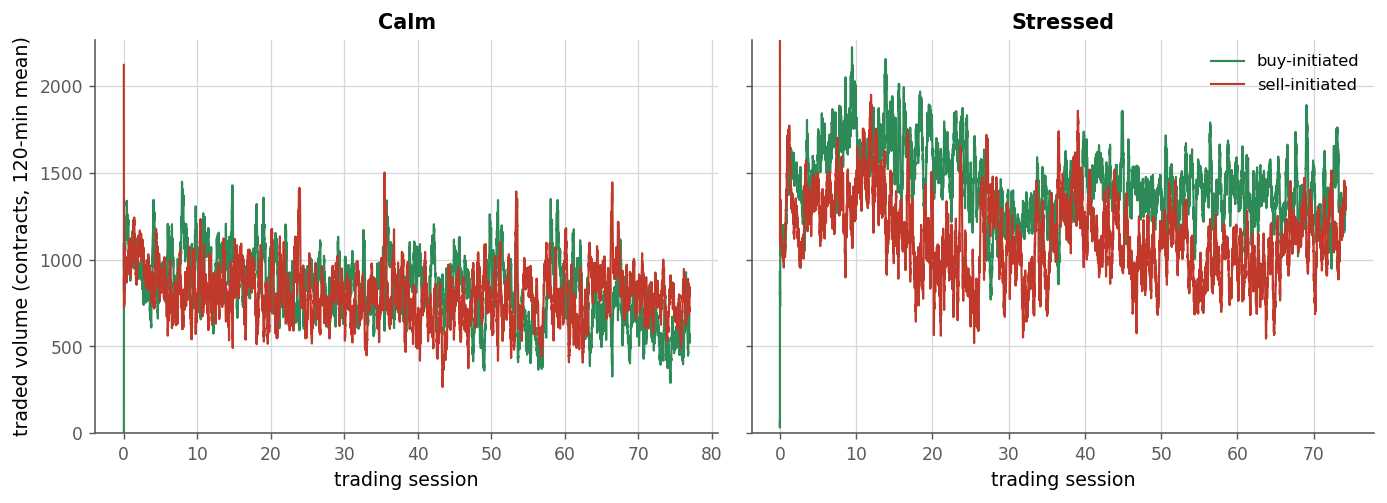

In [16]:
def fig_a_order_flow(CSV, roll=120):
    """A: buy- vs sell-initiated traded volume (rolling mean), representative seed, per regime."""
    df = CSV["representative_timeseries"]
    if df is None: print("[A] no CSV"); return
    regs = list(df["regime"].unique())
    fig, axes = plt.subplots(1, len(regs), figsize=(5.4*len(regs), 4), sharey=True, squeeze=False)
    cap = max(np.nanpercentile(df[df.regime == rg][col].rolling(roll, min_periods=1).mean(), 99.5)
              for rg in regs for col in ["buy_vol", "sell_vol"]) * 1.12   # drop the t=0 warm-up spike
    for ax, rg in zip(axes[0], regs):
        d = df[df.regime == rg]; x = d["t"].to_numpy()/390.0
        ax.plot(x, d["buy_vol"].rolling(roll, min_periods=1).mean(), color="#2E8B57", lw=1.2, label="buy-initiated")
        ax.plot(x, d["sell_vol"].rolling(roll, min_periods=1).mean(), color="#C0392B", lw=1.2, label="sell-initiated")
        ax.set_ylim(0, cap); ax.set_title(rg.capitalize()); ax.set_xlabel("trading session"); despine(ax)
    axes[0][0].set_ylabel(f"traded volume (contracts, {roll}-min mean)"); axes[0][-1].legend(loc="upper right")
    fig.suptitle("Order flow \u2014 buy- vs sell-initiated volume", fontweight="bold", fontsize=13, y=1.02)
    return savefig(fig, "A_order_flow.png")
fig_a_order_flow(CSV); plt.show()


### A2 — Order-book depth (bid vs ask)

Resting bid (buy-side) and ask (sell-side) depth, rolling mean, in ES contracts. In calm the book is deep and roughly balanced; under stress total depth **collapses** (~4× thinner) and the **buy side thins** — bid depth falls below ask as the price drops and resting buyers withdraw (the disappearing bid).

    saved output/results/A2_book_depth.png


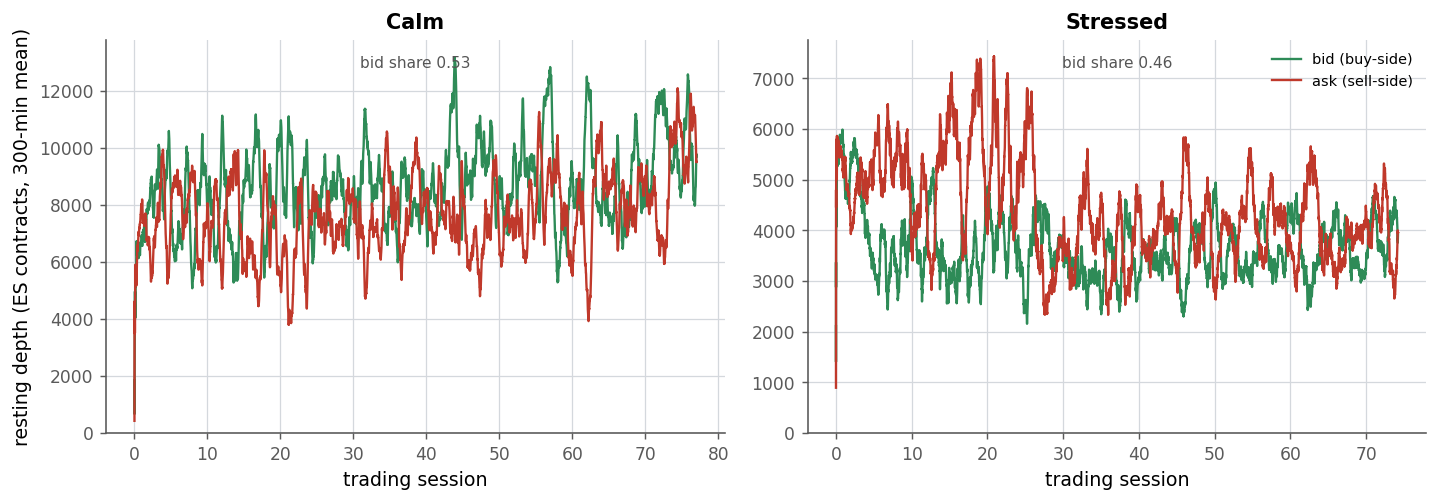

In [17]:
def fig_a2_book_depth(CSV, roll=300):
    """A2: resting bid vs ask depth (rolling mean, contracts), calm vs stressed. Shows the buy side thinning
    under stress. Model order unit = block of ES contracts (calm 18 / stressed 32; see calibration)."""
    df = CSV.get("book_depth")
    if df is None: print("[A2] no book_depth.csv — re-run the descriptive runner"); return
    LOT = {"calm": 18, "stressed": 32}
    regs = [r for r in ["calm", "stressed"] if r in df.regime.unique()]
    fig, axes = plt.subplots(1, len(regs), figsize=(5.6*len(regs), 4), squeeze=False)
    for ax, rg in zip(axes[0], regs):
        d = df[df.regime == rg].sort_values("t"); x = d["t"].to_numpy()/390.0; lot = LOT.get(rg, 1)
        bd = d["bid_depth"].rolling(roll, min_periods=1).mean()*lot
        ad = d["ask_depth"].rolling(roll, min_periods=1).mean()*lot
        ax.plot(x, bd, color="#2E8B57", lw=1.3, label="bid (buy-side)")
        ax.plot(x, ad, color="#C0392B", lw=1.3, label="ask (sell-side)")
        ax.set_ylim(bottom=0); ax.set_title(rg.capitalize()); ax.set_xlabel("trading session")
        share = d["bid_depth"].mean()/(d["bid_depth"].mean()+d["ask_depth"].mean())
        ax.text(0.5, 0.96, f"bid share {share:.2f}", transform=ax.transAxes, ha="center", va="top",
                fontsize=8.5, color="#555"); despine(ax)
    axes[0][0].set_ylabel(f"resting depth (ES contracts, {roll}-min mean)")
    axes[0][-1].legend(loc="upper right", fontsize=8)
    fig.suptitle("Order-book depth \u2014 bid vs ask (the buy side thins under stress)",
                 fontweight="bold", fontsize=13, y=1.02)
    return savefig(fig, "A2_book_depth.png")
fig_a2_book_depth(CSV); plt.show()


### B — Clearing-member capital ratio (the leverage cycle)

Individual member trajectories (representative seed), zoomed to the floor zone. **Client-clearing BCMs** hug the 8% capital-adequacy floor and deleverage toward the 10% restore line; **non-bank members** sit just above; the resilient **house-only banks** (κ≈50%) run off the top. ~3.1/5 client-BCMs breach per stressed seed; **0/40 member defaults** — the cycle fires but members survive.

    saved output/results/B_capital_ratio.png


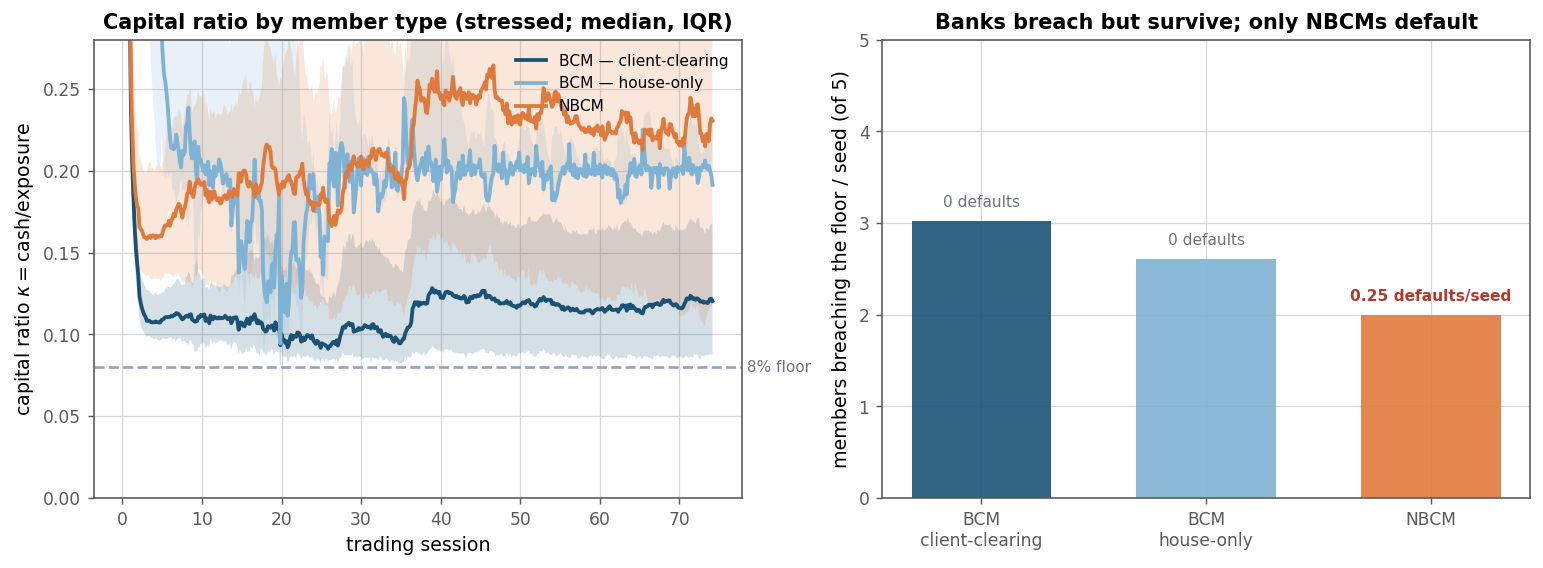

In [18]:
def fig_b_capital(CSV):
    """B: capital ratio kappa by member TYPE (clean 2-panel). Left: median+IQR over the stressed
    window (banks ride the 8% floor; NBCMs sit higher). Right: per-seed floor breaches & defaults
    (banks breach but deleverage and survive; NBCMs breach less but are the only tier that defaults)."""
    import pandas as pd, numpy as np
    band = pd.read_csv(f"{DESC}/capital_ratio_band.csv")
    mc   = pd.read_csv(f"{DESC}/member_clientclearing.csv")
    sm   = pd.read_csv(f"{DESC}/summary_scalars.csv")
    kp   = pd.read_csv(f"{DESC}/member_kappa_path.csv")
    TYPES = [("BCMc","BCM — client-clearing","#1A5276"), ("BCMo","BCM — house-only","#7FB3D5"), ("NBCM","NBCM","#E07A3C")]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    bs = band[band.regime=="stressed"]
    for mt, lab, col in TYPES:
        s = bs[bs.mtype==mt].sort_values("t")
        if s.empty: continue
        x = s["t"].to_numpy()/390.0
        ax[0].fill_between(x, s["p25"], s["p75"], color=col, alpha=0.18, lw=0)
        ax[0].plot(x, s["p50"], color=col, lw=2.1, label=lab)
    ax[0].axhline(LR_FLOOR_BCM, color="#9aa5b1", ls="--", lw=1.5)
    ax[0].text(ax[0].get_xlim()[1], LR_FLOOR_BCM, " 8% floor", color="#6b7280", fontsize=8.5, va="center")
    ax[0].set_ylim(0.0, 0.28); ax[0].set_xlabel("trading session")
    ax[0].set_ylabel(r"capital ratio $\kappa=\mathrm{cash}/\mathrm{exposure}$")
    ax[0].set_title("Capital ratio by member type (stressed; median, IQR)")
    ax[0].legend(loc="upper right", fontsize=8.5, framealpha=0.92)
    mcs = mc[mc.regime=="stressed"]; sms = sm[sm.regime=="stressed"]; kps = kp[kp.regime=="stressed"]
    bcmc_br = mcs[mcs.agent_id.between(30,34)].groupby("seed")["breached"].sum().mean()
    bcmo_br = mcs[mcs.agent_id.between(35,39)].groupby("seed")["breached"].sum().mean()
    nbcm_br = float((kps[kps.mtype=="NBCM"].groupby("agent_id")["capital_ratio"].min() < LR_FLOOR_BCM).sum())
    nbcm_def = sms.nbcm_defaults.mean(); bcm_def = sms.cm_defaults.mean()
    breach = [bcmc_br, bcmo_br, nbcm_br]; deflt = [bcm_def, bcm_def, nbcm_def]
    xx = np.arange(3); cols = [c for _,_,c in TYPES]
    ax[1].bar(xx, breach, 0.62, color=cols, alpha=0.9)
    for xi,(b,d) in enumerate(zip(breach, deflt)):
        tag = f"{d:.2f} defaults/seed" if d>0 else "0 defaults"
        ax[1].text(xi, b+0.12, tag, ha="center", va="bottom", fontsize=8.5,
                   color=("#b03a2e" if d>0 else "#6b7280"), fontweight=("bold" if d>0 else "normal"))
    ax[1].set_xticks(xx); ax[1].set_xticklabels(["BCM\nclient-clearing","BCM\nhouse-only","NBCM"])
    ax[1].set_ylabel("members breaching the floor / seed (of 5)"); ax[1].set_ylim(0, 5.0)
    ax[1].set_title("Banks breach but survive; only NBCMs default")
    fig.suptitle("Members ride the capital floor under stress — but only the non-banks, which cannot deleverage, fail",
                 fontweight="bold", fontsize=12.5, y=1.02)
    return savefig(fig, "B_capital_ratio.png")
fig_b_capital(CSV); plt.show()


### C — Initial margin: dollar path and procyclical fraction

Posted IM (left axis, median + IQR over seeds) and the charged IM fraction (right axis, **matched scales** across panels). Calm holds flat at the 4% anti-procyclicality floor; stressed ramps **4%→11.4% (2.84×)** — the procyclicality signature.

    saved output/results/C_im_path.png


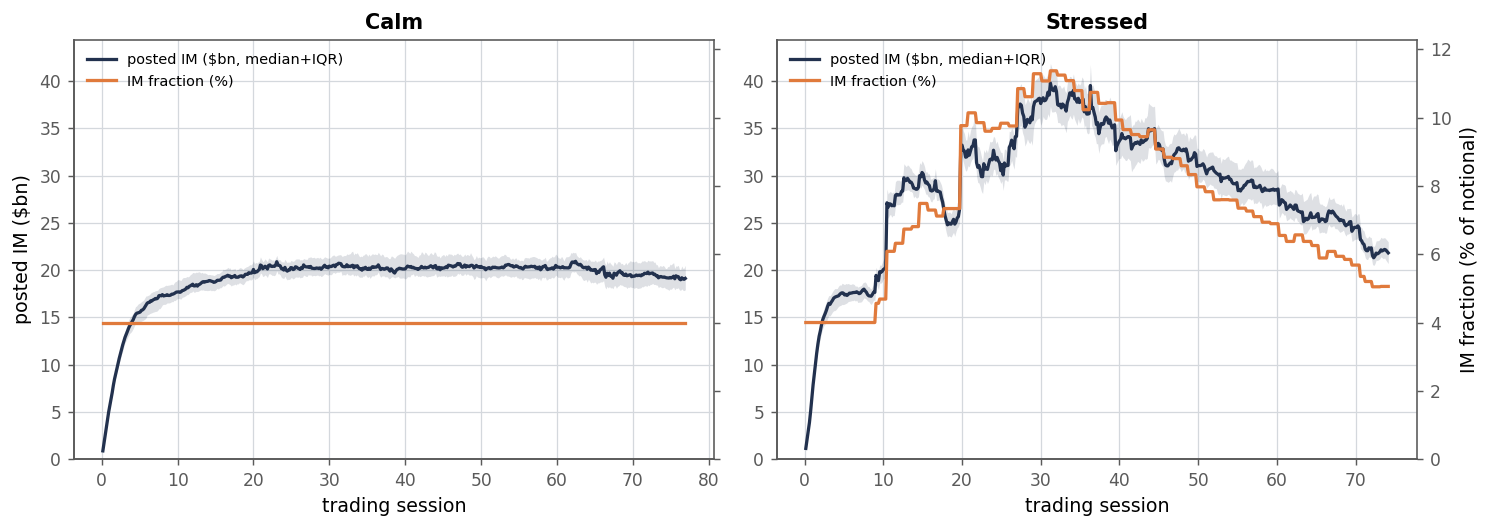

In [19]:
def fig_c_im(CSV):
    """C: dollar IM total (median + IQR) and the procyclical IM fraction, per regime.
    Both panels share the SAME dollar and fraction axes so calm (flat 4%) reads correctly against stressed."""
    df = CSV["im_path"]
    if df is None: print("[C] no CSV"); return
    regs = list(df["regime"].unique())
    dmax = (df["p75"].max()/1e9) * 1.06              # shared $ axis
    fmax = max(12.0, df["im_frac"].max()*100*1.08)   # shared fraction axis
    fig, axes = plt.subplots(1, len(regs), figsize=(5.8*len(regs), 4.2), squeeze=False)
    for j, (ax, rg) in enumerate(zip(axes[0], regs)):
        d = df[df.regime == rg].sort_values("t"); x = d["t"].to_numpy()/390.0
        ax.fill_between(x, d.p25/1e9, d.p75/1e9, color="#22314E", alpha=.15, lw=0)
        ax.plot(x, d.p50/1e9, color="#22314E", lw=1.8, label="posted IM ($bn, median+IQR)")
        ax.set_xlabel("trading session"); ax.set_ylim(0, dmax); despine(ax)
        if j == 0: ax.set_ylabel("posted IM ($bn)")
        ax2 = ax.twinx(); ax2.plot(x, d.im_frac*100, color="#E07A3C", lw=1.8, label="IM fraction (%)")
        ax2.set_ylim(0, fmax); ax2.grid(False)
        if j == len(regs)-1: ax2.set_ylabel("IM fraction (% of notional)")
        else: ax2.set_yticklabels([])
        ax.set_title(rg.capitalize())
        h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, loc="upper left", fontsize=8)
    fig.suptitle("Initial margin \u2014 dollar path and procyclical fraction", fontweight="bold", fontsize=13, y=1.02)
    return savefig(fig, "C_im_path.png")
fig_c_im(CSV); plt.show()


### D — Posted initial margin by participant type

Clients (FT/MT/ZI) vs banking-member house margin. Clients post **~57%** under stress (~60% calm); the share dips slightly under stress because the less-constrained house books scale into the dislocation as margin-capped clients freeze or default.

    saved output/results/D_im_by_type.png


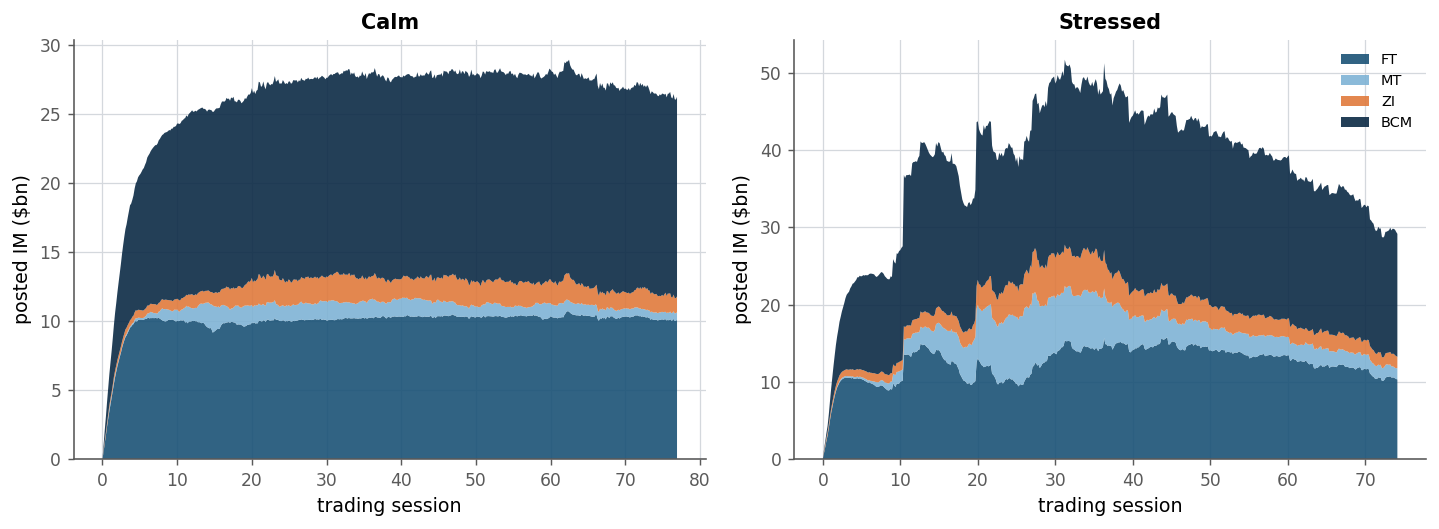

In [20]:
def fig_d_im_type(CSV):
    """D: posted IM by participant type (median over seeds), per regime \u2014 the client share."""
    df = CSV["im_by_type"]
    if df is None: print("[D] no CSV"); return
    regs = list(df["regime"].unique()); types = ["FT","MT","ZI","BCM"]
    fig, axes = plt.subplots(1, len(regs), figsize=(5.6*len(regs), 4.2), sharey=False, squeeze=False)
    for ax, rg in zip(axes[0], regs):
        piv = df[df.regime == rg].pivot_table(index="t", columns="type", values="p50", aggfunc="last").fillna(0.0).sort_index()
        x = piv.index.to_numpy()/390.0; present = [t for t in types if t in piv]
        ax.stackplot(x, *[piv[t].to_numpy()/1e9 for t in present], labels=present,
                     colors=[TYPE_COL[t] for t in present], alpha=.9)
        ax.set_title(rg.capitalize()); ax.set_xlabel("trading session"); despine(ax)
    [a.set_ylabel("posted IM ($bn)") for a in axes[0]]; axes[0][-1].legend(loc="upper right", fontsize=8)
    fig.suptitle("Posted initial margin by participant type (clients FT/MT/ZI vs BCM house)", fontweight="bold", fontsize=13, y=1.02)
    return savefig(fig, "D_im_by_type.png")
fig_d_im_type(CSV); plt.show()


### E — Fundamental $V_t$ vs simulated mid

The clearing-on mid tracks the empirical fundamental and adds endogenous microstructure; the clearing machinery (novation, margining, close-out) does not distort the guaranteed price.

    saved output/results/E_fv_vs_mid.png


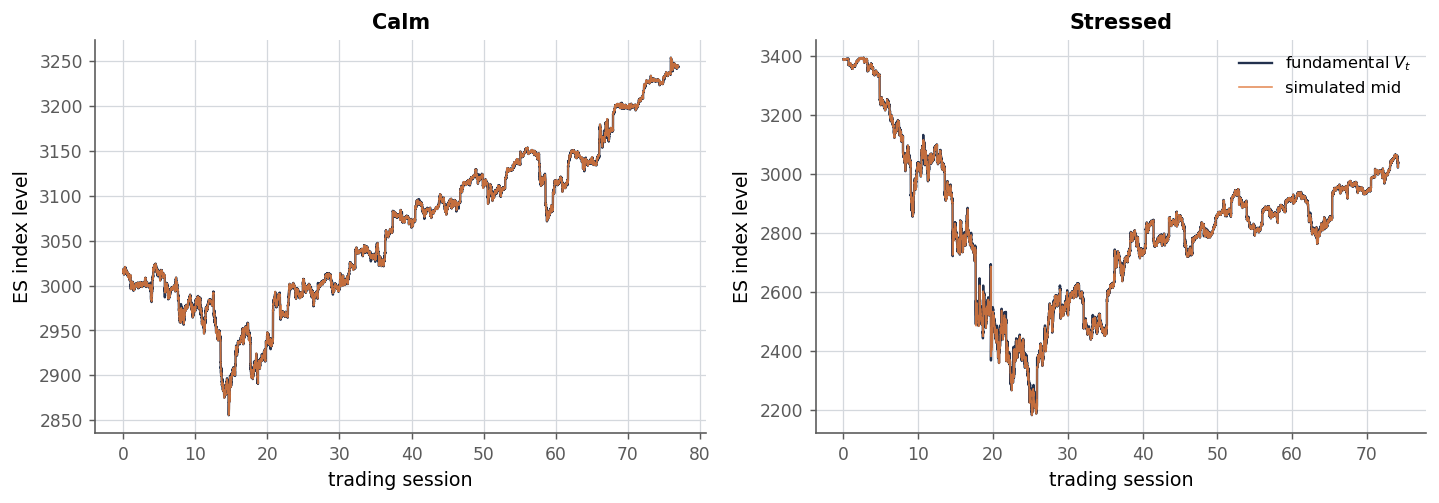

In [21]:
def fig_e_fv_mid(CSV):
    """E: fundamental V_t (= empirical ES mid) vs simulated mid (representative seed), per regime."""
    df = CSV["representative_timeseries"]
    if df is None: print("[E] no CSV"); return
    regs = list(df["regime"].unique())
    fig, axes = plt.subplots(1, len(regs), figsize=(5.6*len(regs), 4), squeeze=False)
    for ax, rg in zip(axes[0], regs):
        d = df[df.regime == rg]; x = d["t"].to_numpy()/390.0
        ax.plot(x, d["V_t"], color="#22314E", lw=1.3, label="fundamental $V_t$")
        ax.plot(x, d["mid"], color="#E07A3C", lw=0.9, alpha=.85, label="simulated mid")
        ax.set_title(rg.capitalize()); ax.set_xlabel("trading session"); ax.set_ylabel("ES index level"); despine(ax)
    axes[0][-1].legend(loc="best")
    fig.suptitle("Fundamental vs simulated mid (clearing active)", fontweight="bold", fontsize=13, y=1.02)
    return savefig(fig, "E_fv_vs_mid.png")
fig_e_fv_mid(CSV); plt.show()


### F — Margin-call monitor (clustering)

The 'margin call' monitor, recreated over the window: per-hour simultaneous calls, median line + cross-seed range band, calm (top) vs stressed (bottom), with MEAN/HIGH/LOW readouts. Calls arrive in **recurrent bursts** (clustering); stressed runs hotter (mean 3.1 vs 1.3 calls/hour, peak ~10).

In [ ]:
def fig_f_margin(CSV=None):
    """F: margin-call clustering — calls/hour over the window (calm top, stressed bottom); bursts
    (>3 calls/hr) are shaded, so the WIDTH of the shaded bands signifies clustering (sustained under
    stress, scattered in calm)."""
    import pandas as pd, numpy as np
    DARK, ORANGE, GREY = "#1A5276", "#E07A3C", "#9aa5b1"; THR = 3
    mh = pd.read_csv(f"{DESC}/margin_calls.csv")
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    for ax, (reg, lab, col) in zip(axes, [("calm","Calm",DARK), ("stressed","Stressed",ORANGE)]):
        g = mh[mh.regime == reg].sort_values("hour")
        x, y = g["hour"].to_numpy(float), g["p50"].to_numpy(float)
        ymax = max(y.max(), THR) + 1
        ax.fill_between(x, 0, ymax, where=(y > THR), color=col, alpha=0.22, step="mid", lw=0)
        ax.plot(x, y, color=col, lw=1.2); ax.axhline(THR, color=GREY, ls="--", lw=1.1)
        ax.set_ylim(0, ymax); ax.set_xlim(x.min(), x.max()); ax.set_ylabel(f"{lab}\nmargin calls / hour")
        ax.text(0.995, 0.90, f"{100*(y>THR).mean():.0f}% of hours in a burst ($>{THR}$/hr)",
                transform=ax.transAxes, ha="right", va="top", fontsize=9, color=col)
    axes[1].set_xlabel("trading hour over the window")
    return savefig(fig, "F_margin_call_clustering.png")
fig_f_margin(CSV); plt.show()


## Hypotheses — margin procyclicality

Reads `output/thesis_final/experiments/rows.csv` (set `RUN_HYPOTHESES=True` in the setup cell). 12 seeds, full window, **ODD fixed default fund** so the mutualised layer is comparable across margin arms.

In [23]:
def load_rows():
    """Load the experiment output; None (with a clear message) if it does not exist yet."""
    if not os.path.exists(ROWS_CSV):
        print(f"{ROWS_CSV} not found — run scripts/run_thesis_experiments.py first.")
        return None
    df = pd.read_csv(ROWS_CSV)
    print(f"loaded {ROWS_CSV}: {len(df)} rows, columns = {list(df.columns)}")
    return df

ROWS = load_rows()

loaded output/thesis_final/experiments/rows.csv: 1200 rows, columns = ['exp', 'regime', 'seed', 'direct', 'margin', 'decouple', 'drawdown', 'client_defaults', 'cm_defaults', 'nbcm_defaults', 'deepest_waterfall', 'mutualised_l3', 'survivor_l4', 'total_df', 'ccp_cash_used', 'client_loss_absorbed', 'im_mean', 'im_peak']


### H1 — Margin procyclicality: risk relocation and cost

As the standing margin rises, **client defaults fall but member defaults and mutualisation rise** — risk is relocated, not removed (the funding-liquidity channel). Reactive dominates flat-8 on every risk metric at equal average margin; its cost is the stress-time funding spike.

    saved output/results/H1_margin.png


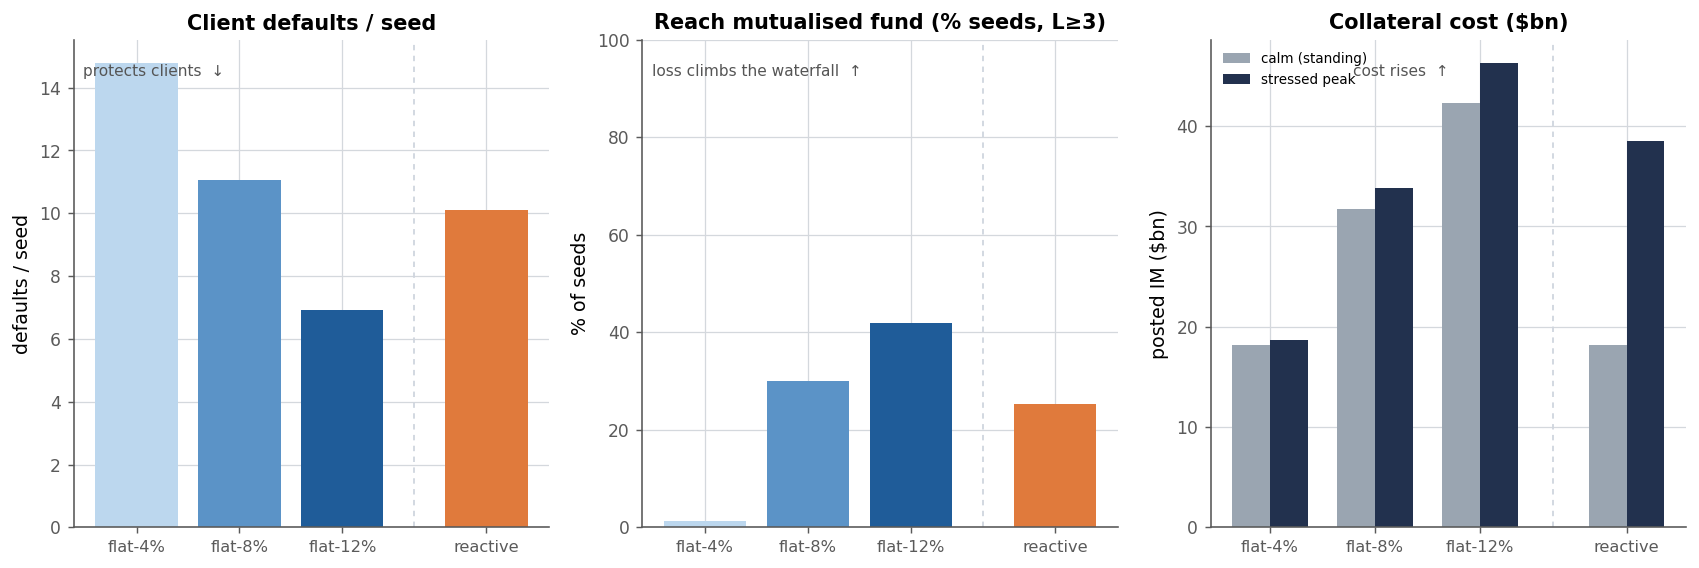

In [24]:
def fig_h1_margin(df):
    """H1 margin trade-off (stressed, 40 seeds), small multiples. The flat ladder (4->8->12%) shows the
    monotonic trade-off; reactive is set off (after the dotted line) and highlighted to show it protects
    as cheaply as flat-4 while landing below flat-8 on every risk metric."""
    order = ["flat04", "flat08", "flat12", "reactive"]; lab = ["flat-4%", "flat-8%", "flat-12%", "reactive"]
    h = df[(df.exp == "H1") & (df.regime == "stressed")].groupby("margin")
    cf = df[(df.exp == "H1") & (df.regime == "calm")].groupby("margin")["im_mean"].mean()
    cd  = [h.get_group(m)["client_defaults"].mean() for m in order]
    mut = [h.get_group(m)["mutualised_l3"].mean()*100 for m in order]
    calm= [cf[m]/1e9 for m in order]; peak = [h.get_group(m)["im_peak"].mean()/1e9 for m in order]
    xpos = [0, 1, 2, 3.4]                      # reactive set off with a gap
    flat = ["#BcD7EE".upper(), "#5B93C7", "#1F5C99"]; rea = "#E07A3C"; cols = flat + [rea]
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13.2, 4.5))
    a1.bar(xpos, cd, 0.8, color=cols); a1.set_title("Client defaults / seed")
    a1.set_ylabel("defaults / seed"); a1.text(0.02, 0.95, "protects clients  \u2193", transform=a1.transAxes,
                                              fontsize=8.5, color="#555", va="top")
    a2.bar(xpos, mut, 0.8, color=cols); a2.set_title("Reach mutualised fund (% seeds, L\u22653)")
    a2.set_ylabel("% of seeds"); a2.set_ylim(0, 100)
    a2.text(0.02, 0.95, "loss climbs the waterfall  \u2191", transform=a2.transAxes, fontsize=8.5, color="#555", va="top")
    w = 0.36
    a3.bar([x-w/2 for x in xpos], calm, w, color="#9aa5b1", label="calm (standing)")
    a3.bar([x+w/2 for x in xpos], peak, w, color="#22314E", label="stressed peak")
    a3.set_title("Collateral cost ($bn)"); a3.set_ylabel("posted IM ($bn)"); a3.legend(fontsize=7.5, loc="upper left")
    a3.text(0.30, 0.95, "cost rises  \u2191", transform=a3.transAxes, fontsize=8.5, color="#555", va="top")
    for a in (a1, a2, a3):
        a.set_xticks(xpos); a.set_xticklabels(lab, fontsize=9); despine(a)
        a.axvline(2.7, color="#cfd5de", ls=(0, (3, 3)), lw=1.0)
    fig.suptitle("The margin trade-off \u2014 raising margin moves loss from clients up the waterfall, at rising cost"
                 "  (reactive, set off, protects as cheaply as flat-4)", fontweight="bold", fontsize=11.5, y=1.0)
    return savefig(fig, "H1_margin.png")
if ROWS is not None:
    fig_h1_margin(ROWS); plt.show()


### Per-arm summary table

Written to `output/results/summary_hypotheses.csv` (client/member defaults, mutualisation, IM, DF by arm).

In [25]:
def table_hyp(df):
    """Per-arm summary -> output/results/summary_hypotheses.csv (+ inline)."""
    d = df.copy(); d["arm"] = d.margin   # H1 only (netting arm dropped)
    agg = d.groupby(["exp", "regime", "arm"]).agg(
        n=("seed", "nunique"), client_def=("client_defaults", "mean"), member_def=("cm_defaults", "mean"),
        deep_wf=("deepest_waterfall", "mean"), mutualised_L3=("mutualised_l3", "mean"),
        IM_bn=("im_mean", lambda s: s.mean()/1e9), DF_bn=("total_df", lambda s: s.mean()/1e9)).reset_index()
    agg.to_csv("output/results/summary_hypotheses.csv", index=False)
    print(agg.round(2).to_string(index=False)); return agg
if ROWS is not None:
    table_hyp(ROWS)


exp   regime      arm   n  client_def  member_def  deep_wf  mutualised_L3  IM_bn  DF_bn
 H1     calm   flat04 150        0.00        0.00     0.00           0.00  18.14  15.21
 H1     calm   flat08 150        0.00        0.00     0.00           0.00  31.73  13.09
 H1     calm   flat12 150        0.00        0.00     0.00           0.00  42.33  11.63
 H1     calm reactive 150        0.00        0.00     0.00           0.00  18.14  15.21
 H1 stressed   flat04 150       14.79        0.01     0.04           0.01  15.30  14.40
 H1 stressed   flat08 150       11.06        0.35     0.91           0.30  28.56  13.02
 H1 stressed   flat12 150        6.91        0.55     1.27           0.42  39.67  11.67
 H1 stressed reactive 150       10.12        0.33     0.79           0.25  26.90  14.03


## Mechanism & robustness — margin relocation (§5.3)

From the 150-seed H1 logs (`output/thesis_final/experiments/`): **why** relocation happens (the freeze-trap), **where** the loss goes (waterfall), **who** defaults (by type), and the **freeze channel** (contagion vs own distress).

<>:49: SyntaxWarning: invalid escape sequence '\$'
<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:49: SyntaxWarning: invalid escape sequence '\$'
<>:55: SyntaxWarning: invalid escape sequence '\g'
/var/folders/n1/hz9fp9dj5wd300076k89wf200000gp/T/ipykernel_37754/3029596562.py:49: SyntaxWarning: invalid escape sequence '\$'
  ax[0].set_ylabel("loss absorbed per seed (\$B)"); ax[0].set_title("Deficit by waterfall layer")
/var/folders/n1/hz9fp9dj5wd300076k89wf200000gp/T/ipykernel_37754/3029596562.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax[1].set_ylabel("events reaching the pooled fund / seed"); ax[1].set_title("Mutualisation frequency ($L \geq 3$)"); _sep(ax[1])


    saved output/results/mech_position.png
    saved output/results/mech_waterfall.png
    saved output/results/mech_defaults_by_type.png
    saved output/results/mech_freezes.png


'output/results/mech_freezes.png'

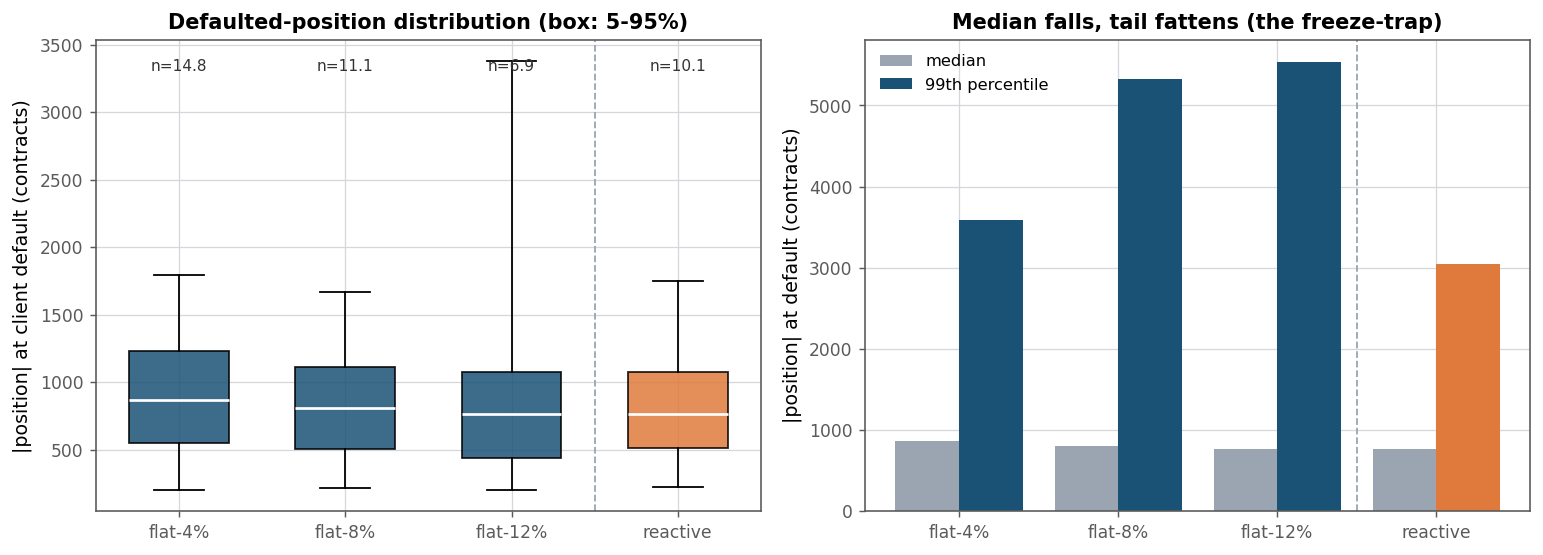

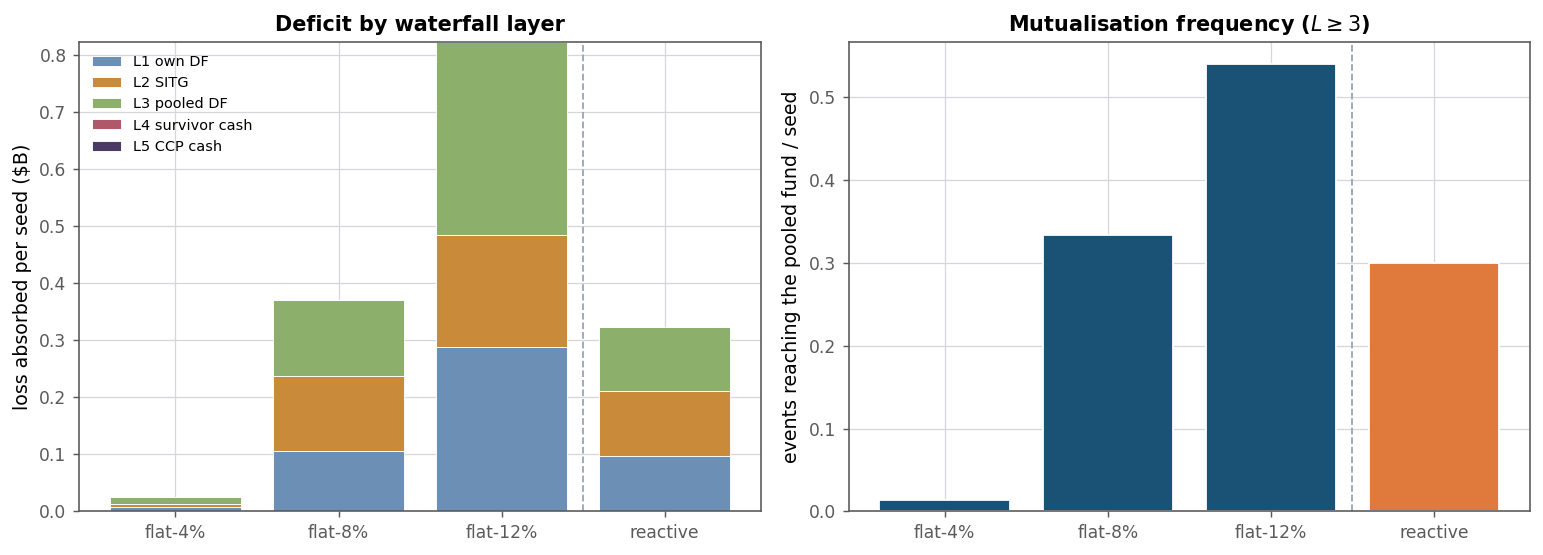

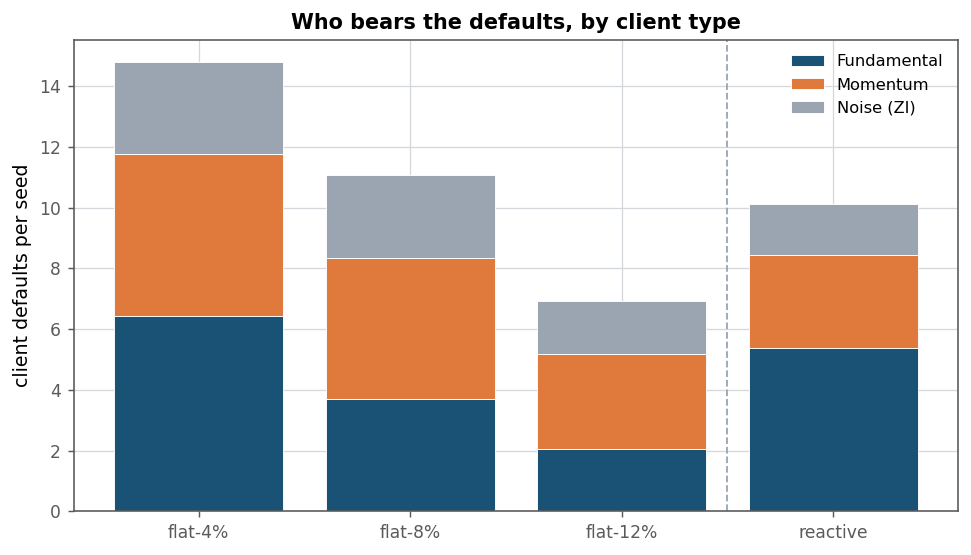

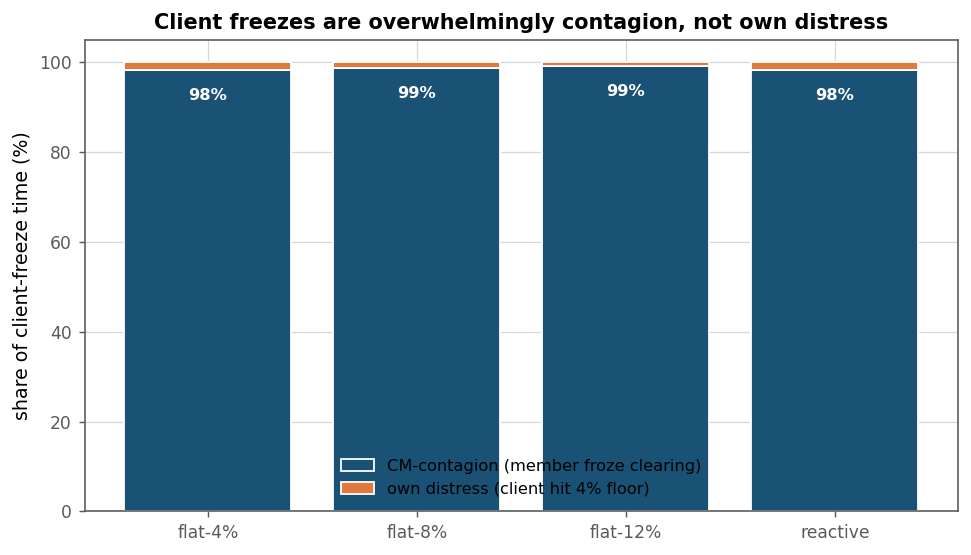

In [26]:
# ============================================================================
# Mechanism & robustness (Â§5.3)  --  150-seed H1 logs (stressed).
# client_defaults / waterfall_events / client_freezes in output/thesis_final/experiments/.
# ============================================================================
E = "output/thesis_final/experiments"
REGIME, N_SEEDS = "stressed", 150
ARMS  = ["flat04", "flat08", "flat12", "reactive"]
LABEL = {"flat04": "flat-4%", "flat08": "flat-8%", "flat12": "flat-12%", "reactive": "reactive"}
FLAT, REACT, GREY = "#1A5276", "#E07A3C", "#9aa5b1"
BARCOL = [FLAT, FLAT, FLAT, REACT]
cd = pd.read_csv(f"{E}/client_defaults.csv"); cd = cd[cd.regime == REGIME].copy(); cd["abspos"] = cd["assumed_pos"].abs()
wf = pd.read_csv(f"{E}/waterfall_events.csv"); wf = wf[wf.regime == REGIME].copy()
fz = pd.read_csv(f"{E}/client_freezes.csv"); fz = fz[fz.regime == REGIME].copy()
def _sep(ax): ax.axvline(2.5, color=GREY, ls="--", lw=1.0, zorder=1)

# M1  --  position at default (the freeze-trap): fewer, smaller median, fatter tail
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
data = [cd.loc[cd.margin == a, "abspos"].to_numpy() for a in ARMS]
bp = ax[0].boxplot(data, positions=range(4), widths=0.6, showfliers=False, patch_artist=True,
                   medianprops=dict(color="white", lw=1.5), whis=(5, 95))
for patch, c in zip(bp["boxes"], BARCOL): patch.set_facecolor(c); patch.set_alpha(0.85)
for a, xx in zip(ARMS, range(4)):
    ax[0].text(xx, ax[0].get_ylim()[1]*0.96, f"n={(cd.margin==a).sum()/N_SEEDS:.1f}", ha="center", va="top", fontsize=8.5, color="#333")
ax[0].set_xticks(range(4)); ax[0].set_xticklabels([LABEL[a] for a in ARMS])
ax[0].set_ylabel("|position| at client default (contracts)")
ax[0].set_title("Defaulted-position distribution (box: 5-95%)"); _sep(ax[0])
p50 = [np.median(cd.loc[cd.margin == a, "abspos"]) for a in ARMS]
p99 = [np.quantile(cd.loc[cd.margin == a, "abspos"], 0.99) for a in ARMS]
xx = np.arange(4)
ax[1].bar(xx - 0.2, p50, 0.4, color=GREY, label="median")
ax[1].bar(xx + 0.2, p99, 0.4, color=BARCOL, label="99th percentile")
ax[1].set_xticks(xx); ax[1].set_xticklabels([LABEL[a] for a in ARMS])
ax[1].set_ylabel("|position| at default (contracts)")
ax[1].set_title("Median falls, tail fattens (the freeze-trap)"); ax[1].legend(fontsize=9); _sep(ax[1])
fig.suptitle("As flat margin rises, client defaults get fewer and typically smaller  --  but the tail fattens", fontsize=12.5, fontweight="bold", y=1.02)
savefig(fig, "mech_position.png")

# M2  --  waterfall: where the loss goes
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
layers = ["L1_own_df", "L2_sitg", "L3_pooled_df", "L4_survivor_cash", "L5_ccp_cash"]
lnames = ["L1 own DF", "L2 SITG", "L3 pooled DF", "L4 survivor cash", "L5 CCP cash"]
lcols  = ["#6b8fb5", "#c98a3a", "#8caf6b", "#b0586a", "#4b3a63"]
tot = {a: (wf.loc[wf.margin == a, layers].sum() / N_SEEDS / 1e9) for a in ARMS}
bottom = np.zeros(4)
for lay, nm, c in zip(layers, lnames, lcols):
    vals = np.array([tot[a][lay] for a in ARMS])
    ax[0].bar(range(4), vals, bottom=bottom, color=c, label=nm, edgecolor="white", lw=0.5); bottom += vals
ax[0].set_xticks(range(4)); ax[0].set_xticklabels([LABEL[a] for a in ARMS])
ax[0].set_ylabel("loss absorbed per seed (\$B)"); ax[0].set_title("Deficit by waterfall layer")
ax[0].legend(fontsize=8, loc="upper left")
ax[0].text(0.5, 0.97, "L4-L5 implemented but never engaged", transform=ax[0].transAxes, ha="center", va="top", fontsize=8.5, color="#555", bbox=dict(boxstyle="round", fc="white", ec=GREY, alpha=0.9)); _sep(ax[0])
mut = [(wf[(wf.margin == a) & (wf.level >= 3)].shape[0]) / N_SEEDS for a in ARMS]
ax[1].bar(range(4), mut, color=BARCOL, edgecolor="white")
ax[1].set_xticks(range(4)); ax[1].set_xticklabels([LABEL[a] for a in ARMS])
ax[1].set_ylabel("events reaching the pooled fund / seed"); ax[1].set_title("Mutualisation frequency ($L \geq 3$)"); _sep(ax[1])
fig.suptitle("Higher margin pushes more (and deeper) defaults into the mutualised waterfall", fontsize=12.5, fontweight="bold", y=1.02)
savefig(fig, "mech_waterfall.png")

# M3  --  defaults by client type
fig, ax = plt.subplots(figsize=(7.6, 4.4))
KINDS = ["FundamentalTrader", "MomentumTrader", "ZeroIntelligenceTrader"]; KLAB = ["Fundamental", "Momentum", "Noise (ZI)"]; KCOL = ["#1A5276", "#E07A3C", "#9aa5b1"]
by = cd.groupby(["margin", "kind"]).size().unstack(fill_value=0).reindex(ARMS) / N_SEEDS
bottom = np.zeros(4)
for k, lab, c in zip(KINDS, KLAB, KCOL):
    vals = by[k].to_numpy() if k in by else np.zeros(4)
    ax.bar(range(4), vals, bottom=bottom, color=c, label=lab, edgecolor="white", lw=0.5); bottom += vals
ax.set_xticks(range(4)); ax.set_xticklabels([LABEL[a] for a in ARMS])
ax.set_ylabel("client defaults per seed"); ax.axvline(2.5, color=GREY, ls="--", lw=1.0)
ax.set_title("Who bears the defaults, by client type"); ax.legend(fontsize=9)
savefig(fig, "mech_defaults_by_type.png")

# M4  --  freeze channel: contagion vs own distress
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ct = fz.groupby(["margin", "reason"]).size().unstack(fill_value=0).reindex(ARMS)
share = ct.div(ct.sum(axis=1), axis=0) * 100
cont = share.get("cm_contagion", pd.Series(0, index=ARMS)).to_numpy(); dist = share.get("own_distress", pd.Series(0, index=ARMS)).to_numpy()
ax.bar(range(4), cont, color="#1A5276", label="CM-contagion (member froze clearing)", edgecolor="white")
ax.bar(range(4), dist, bottom=cont, color="#E07A3C", label="own distress (client hit 4% floor)", edgecolor="white")
for x2, c in enumerate(cont): ax.text(x2, c - 4, f"{c:.0f}%", ha="center", va="top", color="white", fontsize=9, fontweight="bold")
ax.set_xticks(range(4)); ax.set_xticklabels([LABEL[a] for a in ARMS])
ax.set_ylabel("share of client-freeze time (%)"); ax.set_ylim(0, 105)
ax.set_title("Client freezes are overwhelmingly contagion, not own distress"); ax.legend(fontsize=9, loc="lower center")
savefig(fig, "mech_freezes.png")
